## Análisis de datos - Clase 2

#### Actividad: primera inspección del dataset y sus variables

Importar y hacer una exploración inicial del dataset datasets/datos.csv para responer las preguntas que se encuentran a continuación.
Tip: pueden ser útiles los métodos `head()/tail()`, `info()`, `unique()`,`nunique()`, `value_counts()` y las propiedades `shape` y `columns` de pandas.

**Identificar esta información:**

1. Número de filas y columnas: 
2. Nombres de las columnas: 
3. Variables numéricas (y subtipo): 
4. Variables categóricas (y subtipo): 
5. ¿Tiene datos faltantes el dataset?


**Respuestas:**

1. Número de filas y columnas: 


2. Nombres de las columnas: `age`, `workclass`, `education-num`, `marital-status`, `occupation`, `sex`, `capital-gain`, `hours-per-week`, `income`. 

3. Variables numéricas (y subtipo): 

* Numéricas continuas: `capital-gain`, `hours-per-week`

* Numéricas discretas: `age` (continua, reportada como discreta)

4. Variables categóricas (y subtipo): 

* Categóricas ordinales: `education` 

* Categóricas nominales: `marital-status`, `occupation`, `workclass`

* Categórica binaria: `income` , `sex`

5. ¿Tiene datos faltanes el dataset?: no hay NaN, pero hay celdas con " ?" en `workclass`, `occupation`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Importar datasets/datos.csv en un df de Pandas
df = pd.read_csv("../datasets/datos.csv", sep=",")

In [6]:
# Visualizar las primeras filas del dataset
df.head()

,age,workclass,education,marital-status,occupation,sex,capital-gain,hours-per-week,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Male,2174,40,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Male,0,13,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Male,0,40,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Male,0,40,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Female,0,40,<=50K


In [7]:
# Número de filas y columnas del dataset
df.shape

(32561, 9)

In [35]:
# Nombres de las columnas del dataset
df.columns.to_list()

['age',
 'workclass',
 'education',
 'marital-status',
 'occupation',
 'sex',
 'capital-gain',
 'hours-per-week',
 'income']

In [15]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   education       32561 non-null  object
 3   marital-status  32561 non-null  object
 4   occupation      32561 non-null  object
 5   sex             32561 non-null  object
 6   capital-gain    32561 non-null  int64 
 7   hours-per-week  32561 non-null  int64 
 8   income          32561 non-null  object
dtypes: int64(3), object(6)
memory usage: 2.2+ MB


In [ ]:
# Explorar las variables (por ejemplo los valores únicos)
for columns in df.columns:
    total_unicos = df[columns].nunique()
    print(f"Columna: {columns} - total de valores únicos: {total_unicos}")

    if total_unicos < 20:
        print(df[columns].value_counts())
    print("\n")

Columna: age - total de valores únicos: 73


Columna: workclass - total de valores únicos: 9
workclass
 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
 ?                    1836
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: count, dtype: int64


Columna: education - total de valores únicos: 16
education
 HS-grad         10501
 Some-college     7291
 Bachelors        5355
 Masters          1723
 Assoc-voc        1382
11th              1175
 Assoc-acdm       1067
10th               933
7th-8th            646
 Prof-school       576
9th                514
12th               433
 Doctorate         413
5th-6th            333
1st-4th            168
 Preschool          51
Name: count, dtype: int64


Columna: marital-status - total de valores únicos: 7
marital-status
 Married-civ-spouse       14976
 Never-married            10683
 Divorced                  4443
 Separa

In [37]:
raros = [' ?', '? ', '?', 'N/A', 'n.a.', '-', 'missing', '.']
df.isin(raros).any()

age               False
workclass          True
education         False
marital-status    False
occupation         True
sex               False
capital-gain      False
hours-per-week    False
income            False
dtype: bool

In [38]:
# Ejemplo: convertir los valores raros a NaN
df.replace(raros, pd.NA, inplace=True)
df.isin(raros).any()

age               False
workclass         False
education         False
marital-status    False
occupation        False
sex               False
capital-gain      False
hours-per-week    False
income            False
dtype: bool

In [40]:
print(f"Valores faltantes:\n{df.isna().sum()}")  # Calcular valores faltantes

Valores faltantes:
age                  0
workclass         1836
education            0
marital-status       0
occupation        1843
sex                  0
capital-gain         0
hours-per-week       0
income               0
dtype: int64


In [41]:
print("Cantidad de datos duplicados:", df.duplicated().sum())

Cantidad de datos duplicados: 6248


In [42]:
print(f"Columnas del dataframe:\n{df.dtypes}\n")

Columnas del dataframe:
age                int64
workclass         object
education         object
marital-status    object
occupation        object
sex               object
capital-gain       int64
hours-per-week     int64
income            object
dtype: object



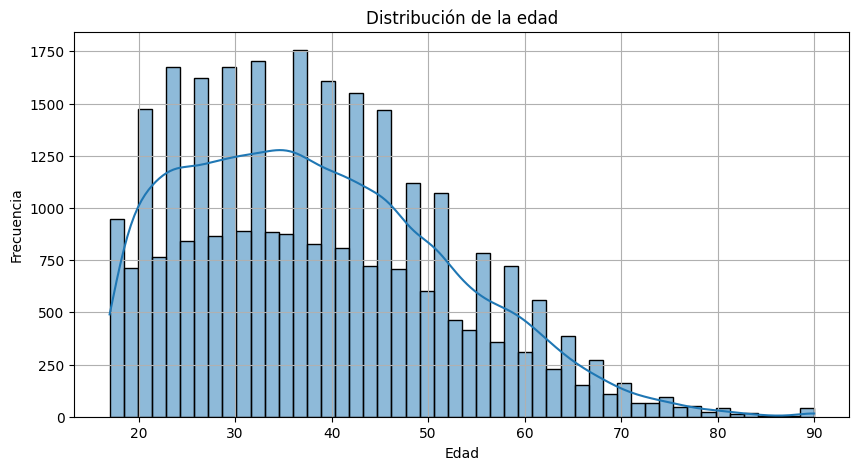

In [33]:
# Distribución de la edad

plt.figure(figsize=(10,5))
sns.histplot(df["age"], bins=50, kde=True)
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de la edad")
plt.grid(True)

plt.show()